In [ ]:
# Pedro Pastro Xavier de Oliveira
# NUSP 10823390
# Atividade 1

In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.style.use('default')
import scipy as sp

#### Coleta de dados

In [2]:
df = pd.read_excel("/Users/pedrodeoliveira/Documents/Python/Poli/Pr. Estocásticos/2024TemposAtracacao.xlsx", sheet_name='2024Atracacao')

# Porto designado: São Sebastião
df = df.loc[df['Complexo Portuário'] == 'São Sebastião']

# Terminal escolhido, por ampla utilização: Terminal Aquaviário de São Sebastião (Almirante Barroso)
df = df.loc[df['Terminal'] == 'Terminal Aquaviário de São Sebastião (Almirante Barroso)']

# Dataframe a ser utilizado
df

,IDAtracacao,CDTUP,IDBerco,Berço,Porto Atracação,Coordenadas,Apelido Instalação Portuária,Complexo Portuário,Tipo da Autoridade Portuária,Data Atracação,...,Tipo de Navegação da Atracação,Nacionalidade do Armador,FlagMCOperacaoAtracacao,Terminal,Município,UF,SGUF,Região Geográfica,Nº da Capitania,Nº do IMO
3330,1448209,BRSP006,BRSP0060004,P4,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-04-10 07:42:00,...,Longo Curso,2.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9867798.0
3333,1448211,BRSP006,BRSP0060004,P4,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-04-15 13:12:00,...,Longo Curso,2.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9867798.0
3338,1459684,BRSP006,BRSP0060004,P4,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-05-11 09:18:00,...,Longo Curso,2.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9867798.0
4600,1448205,BRSP006,BRSP0060003,P3,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-04-29 10:30:00,...,Cabotagem,2.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9858577.0
4603,1420622,BRSP006,BRSP0060002,P2,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-01-27 16:42:00,...,Cabotagem,2.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9858577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50596,1459702,BRSP006,BRSP0060001,P1,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-05-21 05:30:00,...,Cabotagem,1.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9593438.0
50597,1459711,BRSP006,BRSP0060001,P1,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-05-25 04:45:00,...,Cabotagem,1.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9593438.0
50898,1469972,BRSP006,BRSP0060004,P4,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-06-12 19:42:00,...,Cabotagem,2.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9457713.0
51660,1469995,BRSP006,BRSP0060004,P4,Terminal Aquaviário de São Sebastião (Almirant...,"-45.3861,-23.8039",TEBAR,São Sebastião,Terminal Autorizado,2024-06-23 17:42:00,...,Cabotagem,2.0,1,Terminal Aquaviário de São Sebastião (Almirant...,São Sebastião,São Paulo,SP,Sudeste,NaN,9022831.0


#### Índice de colunas

In [3]:
print(list(df.columns))

['IDAtracacao', 'CDTUP', 'IDBerco', 'Berço', 'Porto Atracação', 'Coordenadas', 'Apelido Instalação Portuária', 'Complexo Portuário', 'Tipo da Autoridade Portuária', 'Data Atracação', 'Data Chegada', 'Data Desatracação', 'Data Início Operação', 'Data Término Operação', 'Ano', 'Mes', 'Tipo de Operação', 'Tipo de Navegação da Atracação', 'Nacionalidade do Armador', 'FlagMCOperacaoAtracacao', 'Terminal', 'Município', 'UF', 'SGUF', 'Região Geográfica', 'Nº da Capitania', 'Nº do IMO']


In [4]:
c = []
for i in range(65, 65+26):
    c.append(chr(i))
c.append('AA')

print(list(df.columns)[c.index('K')], end=' | coluna: ')
print(c.index('K'))

Data Chegada | coluna: 10


In [5]:
n = "Data Chegada"
print(list(df.columns).index(n))
print(f'{n} | coluna: {c[list(df.columns).index(n)]}')

10
Data Chegada | coluna: K


#### Análise de dados

In [6]:
# Tempos de fila, em horas
tempo_fila = np.array(df['Data Atracação'] - df['Data Chegada']).astype('float')/(3600*10**9)

# Tempos de pré-operação, em horas
tempo_preOp = np.array(df['Data Início Operação'] - df['Data Atracação']).astype('float')/(3600*10**9)

# Tempos de operação, em horas
tempo_op = np.array(df['Data Término Operação'] - df['Data Início Operação']).astype('float')/(3600*10**9)

# Tempos de pós-operação, em horas
tempo_posOp = np.array(df['Data Desatracação'] - df['Data Término Operação']).astype('float')/(3600*10**9)

In [7]:
# Função para a identificação de outliers
def id_outliers(lista):
    percentil_25 = np.percentile(lista, 25)
    percentil_75 = np.percentile(lista, 75) 
    iqr = percentil_75 - percentil_25 
    outliers = [x for x in lista if x < (percentil_25 - 1.5 * iqr) or x > (percentil_75 + 1.5 * iqr)]
    
    print(f'Q1 = {percentil_25}; Q3 = {percentil_75}')
    print(f'Outliers: {outliers}')

# Função para o cálculo de estatísticas descritivas gerais
def estat(lista):
    media = np.mean(lista)
    mediana = np.median(lista)
    moda = sp.stats.mode(lista)[0]
    desvio_padrao = np.std(lista)
    variancia = np.var(lista)
    coef_var = desvio_padrao/media
    maximo = max(lista)
    minimo = min(lista)
    A = maximo - minimo
    
    print(f'Média = {media:.2f}')
    print(f'Mediana = {mediana}')
    print(f'Moda = {moda}')
    print(f'Desvio Padrão = {desvio_padrao:.2f}')
    print(f'Variânciao = {variancia:.2f}')
    print(f'Coeficiente de Variação = {coef_var:.2f}')
    print(f'Valor máximo = {maximo}; Valor mínimo = {minimo}')
    print(f'Amplitude = {A:.2f}')

# Funcao para testes de aderencia
def teste_ade(data):
    print('-=-=-=-=-= TESTES DE ADERÊNCIA -=-=-=-=-=')
    # Teste de distribuição Normal
    stat, p = sp.stats.shapiro(data)
    print(f"Distribuição Normal: estatística={stat:.3f}, p-valor={p:.3f}")
    if p < 0.05:
        print("Rejeita a hipótese de aderência à Distr. Normal.")
    else:
        print("Não rejeita a hipótese de aderência à Distr. Normal.")
    print()
    

    # Teste de distribuição t de Student
    stat, p = sp.stats.ttest_1samp(data, 0)
    print(f"Distribuição t de Student: estatística={stat:.3f}, p-valor={p:.3f}")
    if p < 0.05:
        print("Rejeita a hipótese de aderência à Distr. t de Student.")
    else:
        print("Não rejeita a hipótese de aderência à Distr. t de Student.")
    print()

    # Teste de distribuição Chi-quadrado
    stat, p, dof, esp = sp.stats.chi2_contingency(np.array([data, data]))
    print(f"Distribuição Chi-quadrado: estatística={stat:.3f}, p-valor={p:.3f}, dof={dof}")
    if p < 0.05:
        print(f"Rejeita a hipótese de aderência à Distr. Chi-quadrado, com {dof} graus de liberdade.")
    else:
        print(f"Não rejeita a hipótese de aderência à Distr. Chi-quadrado, com {dof} graus de liberdade.")
    print()

    # Teste Kolmogorov-Smirnov
    stat, p = sp.stats.kstest(data, 'norm')
    print(f"Teste Kolmogorov-Smirnov: estatística={stat:.3f}, p-valor={p:.3f}")
    if p < 0.05:
        print("Rejeita a hipótese nula.")
    else:
        print("Não rejeita a hipótese nula.")

#### Tempo de fila

In [8]:
# Estatísticas gerais
estat(tempo_fila)

Média = 57.12
Mediana = 24.0
Moda = 2.5
Desvio Padrão = 89.69
Variânciao = 8044.97
Coeficiente de Variação = 1.57
Valor máximo = 729.5; Valor mínimo = 0.016666666666666666
Amplitude = 729.48


In [9]:
# Outliers
id_outliers(tempo_fila)

Q1 = 4.7; Q3 = 71.6
Outliers: [np.float64(644.0), np.float64(290.5), np.float64(205.7), np.float64(298.4), np.float64(729.5), np.float64(212.2), np.float64(250.8), np.float64(290.0), np.float64(281.5), np.float64(434.7), np.float64(224.08333333333334), np.float64(368.75), np.float64(374.4), np.float64(259.8), np.float64(213.5), np.float64(219.6), np.float64(439.2), np.float64(186.5), np.float64(243.1), np.float64(395.0), np.float64(317.6), np.float64(279.7), np.float64(232.0), np.float64(176.4), np.float64(292.1666666666667), np.float64(235.7), np.float64(388.4)]


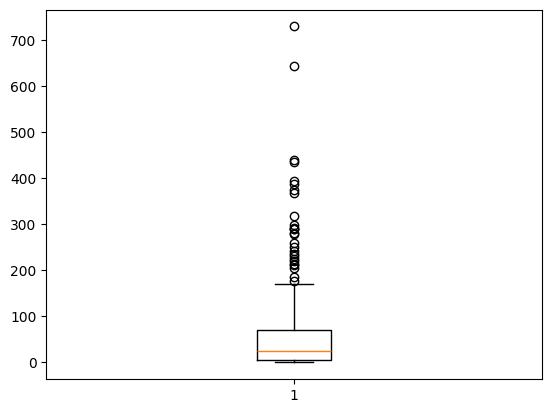

In [10]:
# Boxplot
plt.boxplot(tempo_fila);

(array([189.,  71.,  25.,  19.,  17.,  16.,  13.,   2.,   3.,   5.,   2.,
          4.,   2.,   1.,   0.,   3.,   1.,   1.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([1.66666667e-02, 2.43327778e+01, 4.86488889e+01, 7.29650000e+01,
        9.72811111e+01, 1.21597222e+02, 1.45913333e+02, 1.70229444e+02,
        1.94545556e+02, 2.18861667e+02, 2.43177778e+02, 2.67493889e+02,
        2.91810000e+02, 3.16126111e+02, 3.40442222e+02, 3.64758333e+02,
        3.89074444e+02, 4.13390556e+02, 4.37706667e+02, 4.62022778e+02,
        4.86338889e+02, 5.10655000e+02, 5.34971111e+02, 5.59287222e+02,
        5.83603333e+02, 6.07919444e+02, 6.32235556e+02, 6.56551667e+02,
        6.80867778e+02, 7.05183889e+02, 7.29500000e+02]),
 <BarContainer object of 30 artists>)

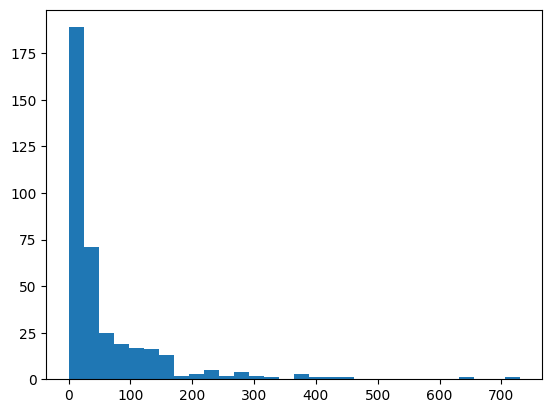

In [11]:
# Histograma
plt.hist(tempo_fila, bins=30)

In [12]:
# Testes de aderência
teste_ade(tempo_fila)

-=-=-=-=-= TESTES DE ADERÊNCIA -=-=-=-=-=
Distribuição Normal: estatística=0.626, p-valor=0.000
Rejeita a hipótese de aderência à Distr. Normal.

Distribuição t de Student: estatística=12.349, p-valor=0.000
Rejeita a hipótese de aderência à Distr. t de Student.

Distribuição Chi-quadrado: estatística=0.000, p-valor=1.000, dof=376
Não rejeita a hipótese de aderência à Distr. Chi-quadrado, com 376 graus de liberdade.

Teste Kolmogorov-Smirnov: estatística=0.969, p-valor=0.000
Rejeita a hipótese nula.


#### Tempo de Pré-operação

In [13]:
# Estatísticas gerais
estat(tempo_preOp)

Média = 5.00
Mediana = 3.7
Moda = 3.5
Desvio Padrão = 5.35
Variânciao = 28.62
Coeficiente de Variação = 1.07
Valor máximo = 60.18333333333333; Valor mínimo = 0.9
Amplitude = 59.28


In [14]:
# Outliers
id_outliers(tempo_preOp)

Q1 = 2.8; Q3 = 5.3
Outliers: [np.float64(48.6), np.float64(9.3), np.float64(12.1), np.float64(13.8), np.float64(13.9), np.float64(15.0), np.float64(18.3), np.float64(12.3), np.float64(9.283333333333333), np.float64(12.3), np.float64(9.7), np.float64(60.18333333333333), np.float64(13.966666666666667), np.float64(12.5), np.float64(9.3), np.float64(37.4), np.float64(9.5), np.float64(9.3), np.float64(27.3), np.float64(9.2), np.float64(10.3), np.float64(9.966666666666667), np.float64(27.1), np.float64(38.7), np.float64(15.3), np.float64(12.966666666666667), np.float64(12.483333333333333), np.float64(9.95), np.float64(15.5), np.float64(14.0), np.float64(12.7), np.float64(11.0)]


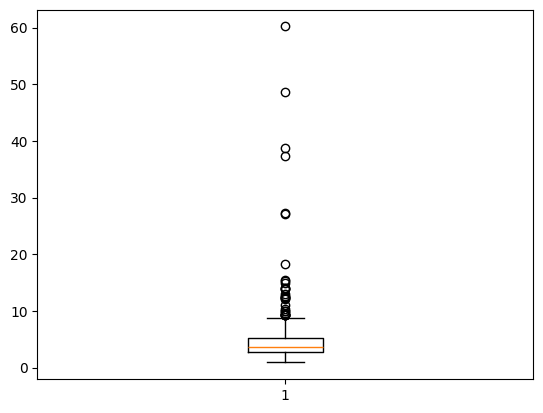

In [15]:
# Boxplot
plt.boxplot(tempo_preOp);

(array([102., 165.,  60.,  18.,  10.,   7.,   5.,   3.,   1.,   0.,   0.,
          0.,   0.,   2.,   0.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([ 0.9       ,  2.87611111,  4.85222222,  6.82833333,  8.80444444,
        10.78055556, 12.75666667, 14.73277778, 16.70888889, 18.685     ,
        20.66111111, 22.63722222, 24.61333333, 26.58944444, 28.56555556,
        30.54166667, 32.51777778, 34.49388889, 36.47      , 38.44611111,
        40.42222222, 42.39833333, 44.37444444, 46.35055556, 48.32666667,
        50.30277778, 52.27888889, 54.255     , 56.23111111, 58.20722222,
        60.18333333]),
 <BarContainer object of 30 artists>)

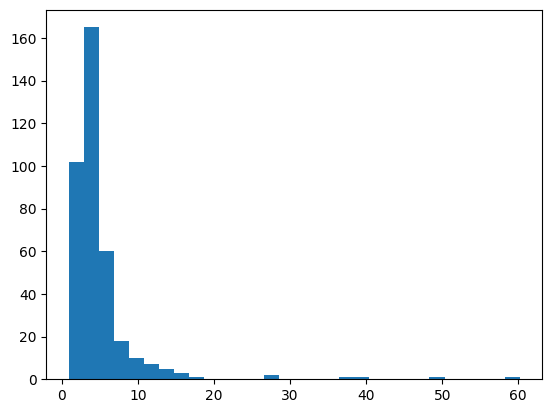

In [16]:
# Histograma
plt.hist(tempo_preOp, bins=30)

In [17]:
# Testes de aderência
teste_ade(tempo_preOp)

-=-=-=-=-= TESTES DE ADERÊNCIA -=-=-=-=-=
Distribuição Normal: estatística=0.450, p-valor=0.000
Rejeita a hipótese de aderência à Distr. Normal.

Distribuição t de Student: estatística=18.133, p-valor=0.000
Rejeita a hipótese de aderência à Distr. t de Student.

Distribuição Chi-quadrado: estatística=0.000, p-valor=1.000, dof=376
Não rejeita a hipótese de aderência à Distr. Chi-quadrado, com 376 graus de liberdade.

Teste Kolmogorov-Smirnov: estatística=0.944, p-valor=0.000
Rejeita a hipótese nula.


#### Tempo de operação

In [18]:
# Estatísticas gerais
estat(tempo_op)

Média = 25.08
Mediana = 22.0
Moda = 15.6
Desvio Padrão = 13.14
Variânciao = 172.77
Coeficiente de Variação = 0.52
Valor máximo = 91.0; Valor mínimo = 0.016666666666666666
Amplitude = 90.98


In [19]:
# Outliers
id_outliers(tempo_op)

Q1 = 16.4; Q3 = 28.3
Outliers: [np.float64(63.5), np.float64(55.81666666666667), np.float64(46.5), np.float64(58.166666666666664), np.float64(50.9), np.float64(86.9), np.float64(46.5), np.float64(46.5), np.float64(50.2), np.float64(48.166666666666664), np.float64(63.7), np.float64(54.2), np.float64(57.9), np.float64(48.9), np.float64(56.2), np.float64(48.6), np.float64(80.8), np.float64(58.416666666666664), np.float64(49.8), np.float64(47.9), np.float64(91.0), np.float64(48.25), np.float64(49.4), np.float64(87.45), np.float64(65.2), np.float64(51.8), np.float64(60.0), np.float64(58.8), np.float64(62.1)]


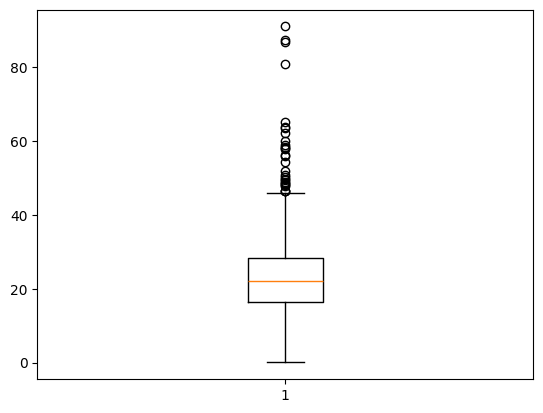

In [20]:
# Boxplot
plt.boxplot(tempo_op);

(array([ 3.,  1.,  5., 19., 40., 50., 54., 52., 44., 26., 16., 11.,  9.,
         6., 11.,  7.,  6.,  2.,  2.,  5.,  3.,  1.,  0.,  0.,  0.,  0.,
         1.,  0.,  2.,  1.]),
 array([1.66666667e-02, 3.04944444e+00, 6.08222222e+00, 9.11500000e+00,
        1.21477778e+01, 1.51805556e+01, 1.82133333e+01, 2.12461111e+01,
        2.42788889e+01, 2.73116667e+01, 3.03444444e+01, 3.33772222e+01,
        3.64100000e+01, 3.94427778e+01, 4.24755556e+01, 4.55083333e+01,
        4.85411111e+01, 5.15738889e+01, 5.46066667e+01, 5.76394444e+01,
        6.06722222e+01, 6.37050000e+01, 6.67377778e+01, 6.97705556e+01,
        7.28033333e+01, 7.58361111e+01, 7.88688889e+01, 8.19016667e+01,
        8.49344444e+01, 8.79672222e+01, 9.10000000e+01]),
 <BarContainer object of 30 artists>)

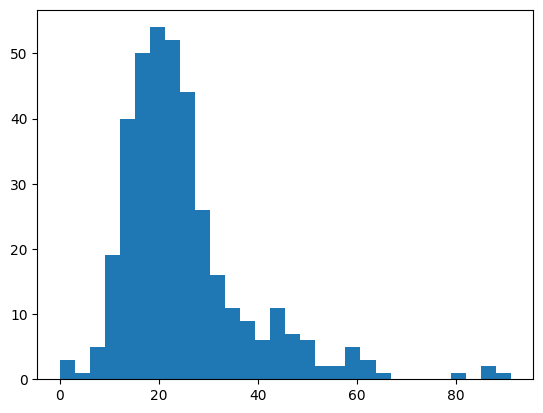

In [21]:
# Histograma
plt.hist(tempo_op, bins=30)

In [22]:
# Testes de aderência
teste_ade(tempo_op)

-=-=-=-=-= TESTES DE ADERÊNCIA -=-=-=-=-=
Distribuição Normal: estatística=0.857, p-valor=0.000
Rejeita a hipótese de aderência à Distr. Normal.

Distribuição t de Student: estatística=36.996, p-valor=0.000
Rejeita a hipótese de aderência à Distr. t de Student.

Distribuição Chi-quadrado: estatística=0.000, p-valor=1.000, dof=376
Não rejeita a hipótese de aderência à Distr. Chi-quadrado, com 376 graus de liberdade.

Teste Kolmogorov-Smirnov: estatística=0.992, p-valor=0.000
Rejeita a hipótese nula.


#### Tempo de Pós-operação

In [23]:
# Estatísticas gerais
estat(tempo_posOp)

Média = 5.41
Mediana = 3.8666666666666667
Moda = 2.5
Desvio Padrão = 5.70
Variânciao = 32.45
Coeficiente de Variação = 1.05
Valor máximo = 55.983333333333334; Valor mínimo = 1.7333333333333334
Amplitude = 54.25


In [24]:
# Outliers
id_outliers(tempo_posOp)

Q1 = 2.7; Q3 = 6.216666666666667
Outliers: [np.float64(20.45), np.float64(15.166666666666666), np.float64(21.366666666666667), np.float64(55.983333333333334), np.float64(46.7), np.float64(55.0), np.float64(12.916666666666666), np.float64(12.8), np.float64(46.05), np.float64(16.266666666666666), np.float64(14.333333333333334), np.float64(25.1), np.float64(17.5), np.float64(18.05), np.float64(14.533333333333333), np.float64(13.983333333333333)]


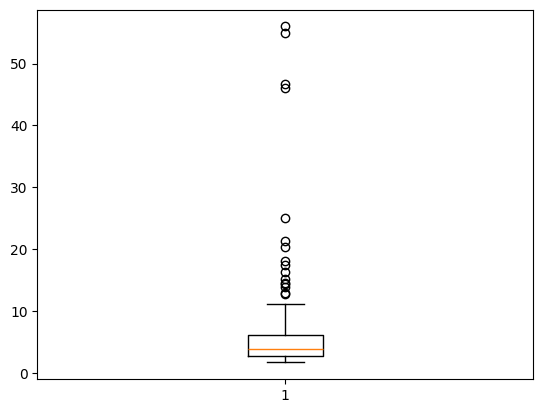

In [25]:
# Boxplot
plt.boxplot(tempo_posOp);

(array([171.,  86.,  46.,  34.,  20.,   4.,   4.,   2.,   2.,   1.,   2.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   2.,   0.,   0.,   0.,   0.,   2.]),
 array([ 1.73333333,  3.54166667,  5.35      ,  7.15833333,  8.96666667,
        10.775     , 12.58333333, 14.39166667, 16.2       , 18.00833333,
        19.81666667, 21.625     , 23.43333333, 25.24166667, 27.05      ,
        28.85833333, 30.66666667, 32.475     , 34.28333333, 36.09166667,
        37.9       , 39.70833333, 41.51666667, 43.325     , 45.13333333,
        46.94166667, 48.75      , 50.55833333, 52.36666667, 54.175     ,
        55.98333333]),
 <BarContainer object of 30 artists>)

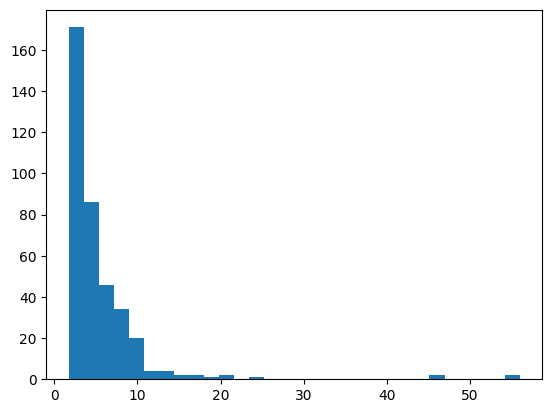

In [26]:
# Histograma
plt.hist(tempo_posOp, bins=30)

In [36]:
# Testes de aderência
teste_ade(tempo_posOp)

-=-=-=-=-= TESTES DE ADERÊNCIA -=-=-=-=-=
Distribuição Normal: estatística=0.469, p-valor=0.000
Rejeita a hipótese de aderência à Distr. Normal.

Distribuição t de Student: estatística=18.411, p-valor=0.000
Rejeita a hipótese de aderência à Distr. t de Student.

Distribuição Chi-quadrado: estatística=0.000, p-valor=1.000, dof=376
Não rejeita a hipótese de aderência à Distr. Chi-quadrado, com 376 graus de liberdade.

Teste Kolmogorov-Smirnov: estatística=0.966, p-valor=0.000
Rejeita a hipótese nula.
